##### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

##### Part 1

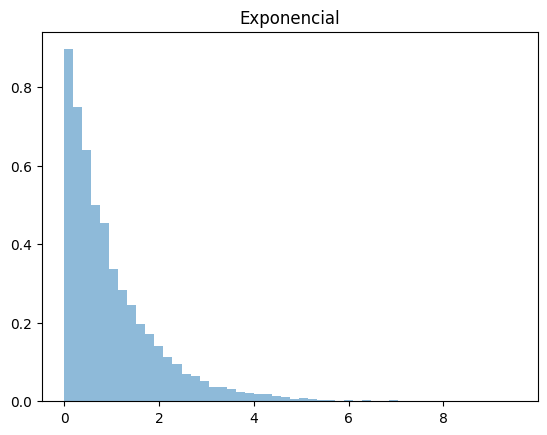

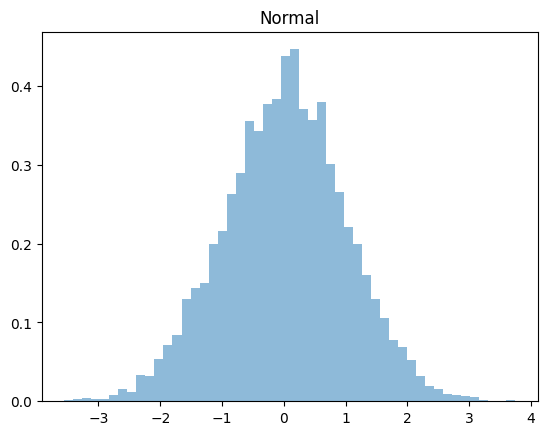

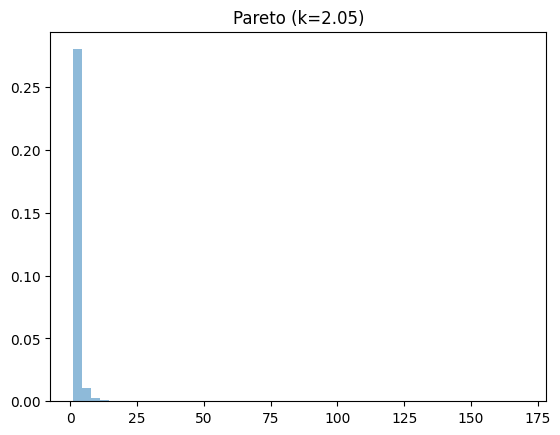

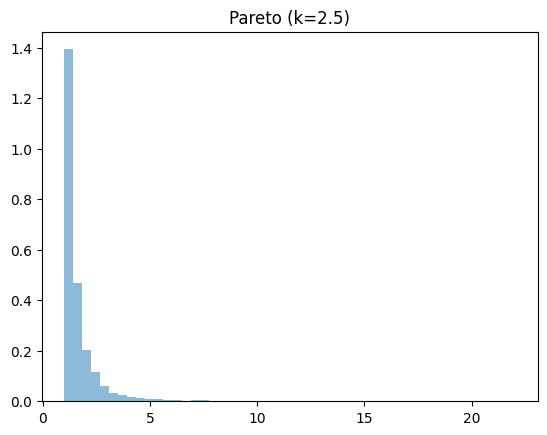

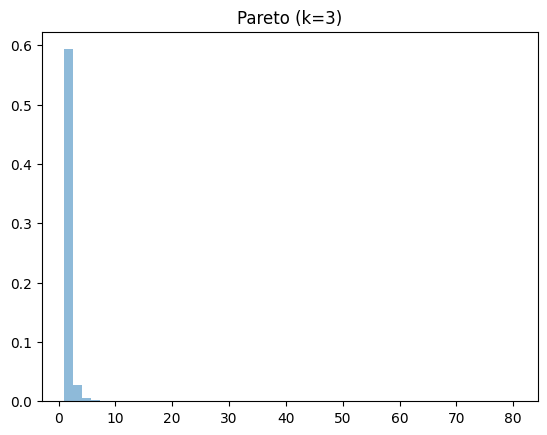

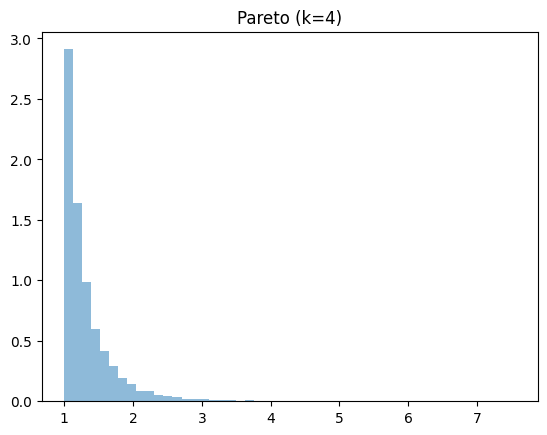

In [2]:
def sample_exponential(n, lambd=1.0):
    return -np.log(1 - np.random.uniform(0, 1, n)) / lambd

def sample_normal(n):
    u1, u2 = np.random.uniform(0, 1, n), np.random.uniform(0, 1, n)
    return np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)

def sample_pareto(n, k=2.05):
    return 1 / (1 - np.random.uniform(0, 1, n))**(1/k)

def verify(samples, title):
    plt.hist(samples, bins=50, density=True, alpha=0.5)
    plt.title(title)
    plt.show()

# Execução
verify(sample_exponential(10000), "Exponencial")
verify(sample_normal(10000), "Normal")

for k in [2.05, 2.5, 3, 4]:
    verify(sample_pareto(10000, k=k), f"Pareto (k={k})")

##### Part 2

In [3]:
def check_moments(k, beta=1.0, n=10000):
    samples = sample_pareto(n, k=k)
    
    sim_mean = np.mean(samples)
    sim_var = np.var(samples)
    
    theo_mean = (beta * k) / (k - 1) if k > 1 else np.inf
    theo_var = (beta**2 * k) / ((k - 1)**2 * (k - 2)) if k > 2 else np.inf
    
    print(f"k={k}")
    print(f"  Mean: Sim={sim_mean:.4f}, Theo={theo_mean:.4f}")
    print(f"  Var:  Sim={sim_var:.4f}, Theo={theo_var:.4f}")
    

# Executar para os valores de k pedidos
for k in [2.05, 2.5, 3, 4]:
    check_moments(k)

k=2.05
  Mean: Sim=1.9134, Theo=1.9524
  Var:  Sim=3.9117, Theo=37.1882
k=2.5
  Mean: Sim=1.6813, Theo=1.6667
  Var:  Sim=2.6146, Theo=2.2222
k=3
  Mean: Sim=1.5094, Theo=1.5000
  Var:  Sim=0.7354, Theo=0.7500
k=4
  Mean: Sim=1.3373, Theo=1.3333
  Var:  Sim=0.2327, Theo=0.2222


##### Part3

In [4]:
def confidence_intervals(num_intervals=100, n=10, confidence=0.95):
    alpha = 1 - confidence
    # Critical values
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
    chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)
    
    mean_hits = 0
    var_hits = 0
    
    # Normal distribution parameters
    mu_true, var_true = 0, 1
    
    for _ in range(num_intervals):
        data = np.random.normal(mu_true, np.sqrt(var_true), n)
        s_mean = np.mean(data)
        s_var = np.var(data, ddof=1)
        
        # Confidence Interval for the Mean
        ci_mean = (s_mean - t_crit * np.sqrt(s_var/n), s_mean + t_crit * np.sqrt(s_var/n))
        if ci_mean[0] <= mu_true <= ci_mean[1]:
            mean_hits += 1
            
        # Confidence Interval for the Variance
        ci_var = ((n-1)*s_var / chi2_upper, (n-1)*s_var / chi2_lower)
        if ci_var[0] <= var_true <= ci_var[1]:
            var_hits += 1
            
    print(f"Mean Coverage: {mean_hits/num_intervals*100}%")
    print(f"Variance Coverage: {var_hits/num_intervals*100}%")

confidence_intervals()

Mean Coverage: 94.0%
Variance Coverage: 94.0%


##### Part 4

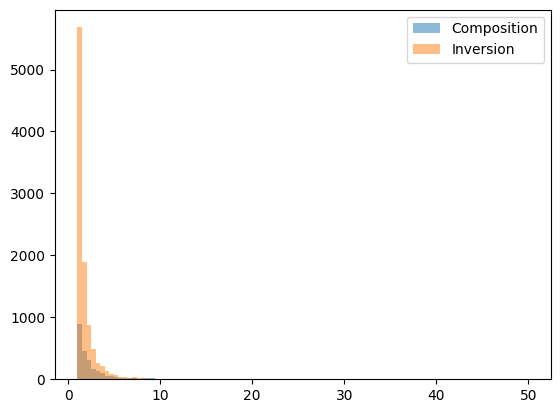

In [5]:
def pareto_composition(n, k=2.05):
    y = np.random.gamma(shape=k, scale=1.0, size=n)
    return np.random.exponential(1.0 / y)


n = 10000
k = 2.05
samples_comp = pareto_composition(n, k)
samples_inv = sample_pareto(n, k) 

plt.hist(samples_comp, bins=np.linspace(1, 50, 100), alpha=0.5, label='Composition')
plt.hist(samples_inv, bins=np.linspace(1, 50, 100), alpha=0.5, label='Inversion')
plt.legend()
plt.show()

In [6]:
def simulate_blocking_system(num_servers, arrival_rate, mean_service_time, num_arrivals, dist_type):
    """
    Simulates an M/G/m/m loss system.
    
    num_servers     : Number of parallel servers (m)
    arrival_rate    : Rate of arrival process (lambda)
    mean_service_time: Mean service duration
    num_arrivals    : Total number of customers to simulate
    dist_type       : Type of service distribution ('constant', 'pareto', etc.)
    """
    
    # Track when each server becomes free
    server_free_time = np.zeros(num_servers)
    blocked_count = 0
    
    # Generate arrival times (Poisson process: inter-arrivals are exponential)
    inter_arrival_times = np.random.exponential(1/arrival_rate, num_arrivals)
    arrival_times = np.cumsum(inter_arrival_times)
    
    for t_arr in arrival_times:
        # Find servers free at the current arrival time
        free_indices = np.where(server_free_time <= t_arr)[0]
        
        if len(free_indices) > 0:
            # Assign the first available server
            idx = free_indices[0]
            
            # Generate service time based on distribution type
            if dist_type == 'constant':
                service_time = mean_service_time
            elif dist_type == 'pareto':
                # Pareto distribution scaled to match the desired mean
                # E[X] = (k * scale) / (k - 1) => scale = mean * (k - 1) / k
                k = 2.05
                scale = mean_service_time * (k - 1) / k
                service_time = (np.random.pareto(k) + 1) * scale
            else:
                # Default to exponential if no distribution specified
                service_time = np.random.exponential(mean_service_time)
            
            # Update the time when this server will be free again
            server_free_time[idx] = t_arr + service_time
        else:
            # Blocked: all servers are currently busy
            blocked_count += 1
            
    return blocked_count / num_arrivals # Blocking probability (B)

# Example usage:
# 5 servers, lambda=1.0, mean_service=2.0, 10,000 arrivals
blocking_prob = simulate_blocking_system(5, 1.0, 2.0, 10000, 'constant')
print(f"Simulated blocking probability: {blocking_prob:.4f}")

Simulated blocking probability: 0.0336
